In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Bagging, or bootstrap aggregation, constructs an ensemble by training identical base models on diverse bootstrap subsets of the training data, reducing variance through aggregation without increasing bias, thereby enhancing generalisation over single high-variance learners like unconstrained decision trees.**

### Distinguishing Ensemble Methods
Ensemble methods broadly aggregate multiple base learners to improve predictive performance. The **voting classifier** employs diverse algorithms on the identical training set, combining predictions via majority vote or averaging to leverage complementary strengths. In contrast, **bagging** utilises a single algorithm across varied subsets of the training data, fostering diversity through data resampling rather than model heterogeneity.

This distinction ensures bagging excels in stabilising unstable learners, while voting harnesses algorithmic variety. Both mitigate overfitting, but bagging specifically targets variance reduction in models prone to perturbation sensitivity.

### Theoretical Foundations of Bagging
**Bootstrap aggregation** (bagging) addresses high variance in base estimators by generating $B$ bootstrap samples from the original dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$. Each bootstrap sample $\mathcal{D}_b$ is drawn with replacement, maintaining size $N$, such that approximately 63.2% of original instances appear (due to $1 - (1 - 1/N)^N \approx 1 - e^{-1}$), with duplicates introducing variability.

Base models $\hat{f}_b(\mathbf{x})$ are trained independently on each $\mathcal{D}_b$. For regression, the ensemble prediction is the average:
$$
\bar{f}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^B \hat{f}_b(\mathbf{x}),
$$
reducing variance to $\frac{1}{B} \sigma^2$ for uncorrelated models, where $\sigma^2$ is individual variance. Bias remains unchanged, as bases are unbiased.

For classification, majority voting yields:
$$
\bar{f}(\mathbf{x}) = \arg\max_k \sum_{b=1}^B \mathbb{I}(\hat{f}_b(\mathbf{x}) = k),
$$
approximating probabilistic modes. Bagging's efficacy relies on base instability: stable learners (low variance) gain minimally, while volatile ones (e.g., deep trees) benefit substantially.

Bootstrapping simulates sampling from the empirical distribution, enabling variance estimation without additional data. Theoretically, as $B \to \infty$, the ensemble converges to an expected model over bootstrap distributions, smoothing irregularities.

### Bootstrap Sampling Mechanism
The **bootstrap** resamples with replacement to create pseudo-datasets mimicking population variability. For a set $\{A, B, C\}$, possible bootstraps include $\{B, B, B\}$ or $\{A, B, A\}$, introducing diversity absent in subsampling without replacement.

This mechanism decorrelates bases, as each sees unique instance multiplicities. In high dimensions, it aids in exploring feature subspaces implicitly.

To demonstrate bootstrapping:

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

X, y = fetch_california_housing(return_X_y=True, as_frame=False)

# Smaller subset for speed and cleaner visuals
rng = np.random.default_rng(42)
idx = rng.choice(np.arange(X.shape[0]), size=3000, replace=False)
X, y = X[idx], y[idx]

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.25, random_state=42
)


In [11]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

n_estimators = 100
base_tree = DecisionTreeRegressor(max_depth=None, min_samples_leaf=5, random_state=0)
bag = BaggingRegressor(
	estimator=base_tree,
	n_estimators=n_estimators,
	max_samples=1.0,
	bootstrap=True,
	oob_score=True,
	random_state=42,
)
bag.fit(X_train, y_train)

print(f"OOB R²: {bag.oob_score_:.3f}")
print(f"Test R²: {bag.score(X_test, y_test):.3f}")


OOB R²: 0.725
Test R²: 0.712


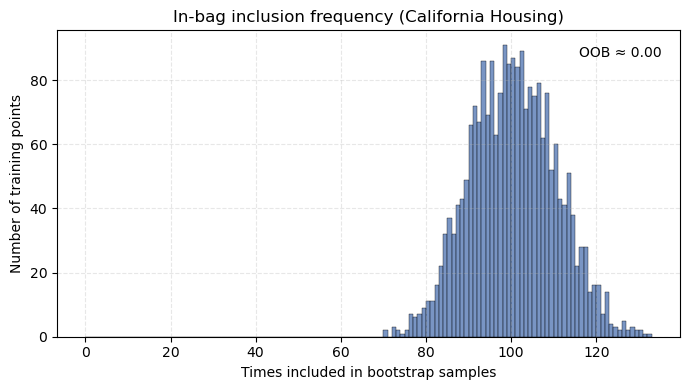

In [12]:
counts = np.zeros(X_train.shape[0], dtype=int)
local_rng = np.random.default_rng(42)
for _ in range(n_estimators):
	sample_idx = local_rng.integers(0, X_train.shape[0], size=X_train.shape[0])
	unique, freq = np.unique(sample_idx, return_counts=True)
	counts[unique] += freq

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
	counts, bins=range(counts.max() + 2), ax=ax, color="#4C72B0", edgecolor="black"
)
ax.set_xlabel("Times included in bootstrap samples")
ax.set_ylabel("Number of training points")
ax.set_title("In-bag inclusion frequency (California Housing)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.text(
	0.97,
	0.95,
	f"OOB ≈ {np.mean(counts == 0):.2f}",
	transform=ax.transAxes,
	ha="right",
	va="top",
	fontsize=10,
)
plt.tight_layout()


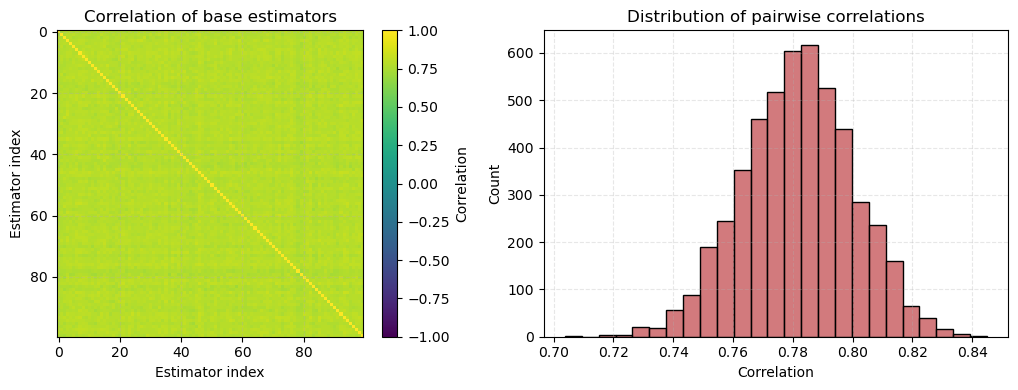

In [13]:
# Compute predictions on test set for each base estimator
pred_matrix = np.column_stack([est.predict(X_test) for est in bag.estimators_])
corr = np.corrcoef(pred_matrix.T)
iu = np.triu_indices_from(corr, k=1)
corr_vals = corr[iu]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(corr, vmin=-1, vmax=1)
cb = plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cb.set_label("Correlation")
ax[0].set_title("Correlation of base estimators")
ax[0].set_xlabel("Estimator index")
ax[0].set_ylabel("Estimator index")

sns.histplot(corr_vals, bins=25, ax=ax[1], color="#C44E52", edgecolor="black")
ax[1].set_title("Distribution of pairwise correlations")
ax[1].set_xlabel("Correlation")
ax[1].set_ylabel("Count")
for a in ax:
	a.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

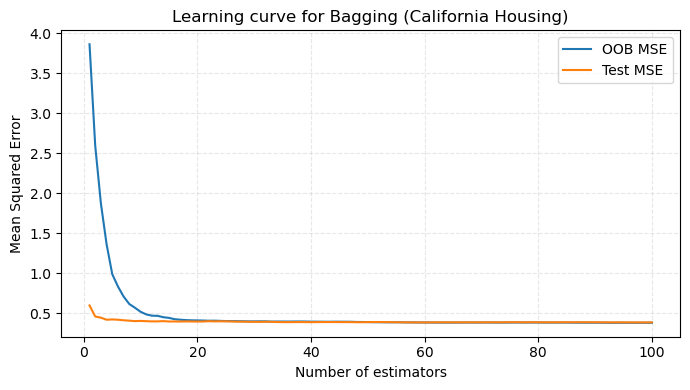

In [17]:
import warnings

from sklearn.metrics import mean_squared_error

oob_curve = []
test_curve = []

for t in range(1, n_estimators + 1):
	with warnings.catch_warnings():
		warnings.simplefilter("ignore", UserWarning)
		bag_curve = BaggingRegressor(
			estimator=DecisionTreeRegressor(min_samples_leaf=5, random_state=0),
			n_estimators=t,
			max_samples=1.0,
			bootstrap=True,
			oob_score=True,
			random_state=42,
		)
		bag_curve.fit(X_train, y_train)

	oob_pred = getattr(bag_curve, "oob_prediction_", None)
	if oob_pred is not None:
		mask = ~np.isnan(oob_pred)
		oob_curve.append(
			mean_squared_error(y_train[mask], oob_pred[mask]) if mask.any() else np.nan
		)
	else:
		oob_curve.append(np.nan)
	test_curve.append(mean_squared_error(y_test, bag_curve.predict(X_test)))

ts = np.arange(1, n_estimators + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, oob_curve, label="OOB MSE")
ax.plot(ts, test_curve, label="Test MSE")
ax.set_xlabel("Number of estimators")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Learning curve for Bagging (California Housing)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


This plot illustrates frequency shifts in bootstraps, highlighting induced variability.


### Bagging for Classification and Regression
In classification, bagging aggregates via majority vote, implemented as `BaggingClassifier` in scikit-learn. This suits binary or multi-class tasks, reducing overfitting in trees.

In regression, averaging predictions via `BaggingRegressor` smooths outputs, dampening noise sensitivity.

Both employ out-of-bag (OOB) instances—unseen in a bootstrap (~36.8%)—for internal validation, enabling OOB error estimation without separate sets.

### Implementation in Scikit-Learn
Scikit-learn's bagging classes wrap base estimators, specifying `n_estimators` for ensemble size and `n_jobs=-1` for parallelism.

Using the Breast Cancer dataset for classification:

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split: 70% train, 30% test (stratified for balance)
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, stratify=y, random_state=42
)

# Base classifier (constrained tree)
base_clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=0.16, random_state=42)

# Bagging ensemble
bagging_clf = BaggingClassifier(
	estimator=base_clf, n_estimators=300, random_state=42, n_jobs=-1
)

# Fit and predict
bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Bagging Classifier Accuracy: {acc:.3f}")

Bagging Classifier Accuracy: 0.930


This yields improved accuracy over the base, demonstrating variance reduction.

For regression, substitute `BaggingRegressor` and MSE.

### Practical Considerations and Extensions
Bagging scales with $B$, but OOB scoring (`oob_score=True`) offers efficient validation. It underperforms if bases are biased, as aggregation preserves bias.

Extensions include random forests, injecting further diversity via feature subsampling. Theoretically, bagging approximates Bayesian model averaging under bootstrap posteriors, justifying its robustness. In practice, tune $B$ until performance plateaus, balancing compute and gains.